<a href="https://colab.research.google.com/github/Bkishorek/Healthcare-Data-Analytics-Portfolio/blob/main/Drug-Side_Effects_Analysis/Drug_Side_Effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drug side effects EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Importing the file
df =pd.read_csv('/content/drugs_side_effects_drugs_com.csv')
df.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [4]:
#rows and columns, column names
print(df.shape)
print(df.columns)


(2931, 17)
Index(['drug_name', 'medical_condition', 'side_effects', 'generic_name',
       'drug_classes', 'brand_names', 'activity', 'rx_otc',
       'pregnancy_category', 'csa', 'alcohol', 'related_drugs',
       'medical_condition_description', 'rating', 'no_of_reviews', 'drug_link',
       'medical_condition_url'],
      dtype='object')


In [5]:
#checking non- null values data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

In [6]:
# removing unnecessary columns
df.drop(columns = ['brand_names'], inplace = True)

In [7]:
#checking duplicates
duplicate_rows = df[df.duplicated()]
duplicate_count = duplicate_rows.shape[0]
print('Duplicate count:',duplicate_count)
duplicate_rows

Duplicate count: 0


,drug_name,medical_condition,side_effects,generic_name,drug_classes,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url


In [8]:
#checking for missing values
df.isnull().sum()

,0
drug_name,0
medical_condition,0
side_effects,124
generic_name,43
drug_classes,82
activity,0
rx_otc,1
pregnancy_category,229
csa,0
alcohol,1554


In [9]:
#Dealing with missing values
#Filling alcohol

df['alcohol'] = df['alcohol'].replace(pd.NA, '0')
df['alcohol'] = df['alcohol'].replace({'X': 1})

#Filling side effects

df['side_effects'] = df['side_effects'].fillna('Unknown')

#filling related_drugs
df['related_drugs'] = df['related_drugs'].fillna('Unknown')

#Filling rating
df['rating'] = df['rating'].fillna(0)

#filling no_of_reviews
df['no_of_reviews'] = df['no_of_reviews'].fillna(0)

#filling generic nmae
df['generic_name'] = df['generic_name'].fillna('Unknown')

#filling drug_classes
df['drug_classes'] = df['drug_classes'].fillna('Unknown')

#filling rx_otc
df['rx_otc'] = df['rx_otc'].fillna('Unknown')

#filling pregnancy_category
df['pregnancy_category'] = df['pregnancy_category'].fillna('Unknown')


In [10]:
#checking missing values again
df.isnull().sum()

,0
drug_name,0
medical_condition,0
side_effects,0
generic_name,0
drug_classes,0
activity,0
rx_otc,0
pregnancy_category,0
csa,0
alcohol,0


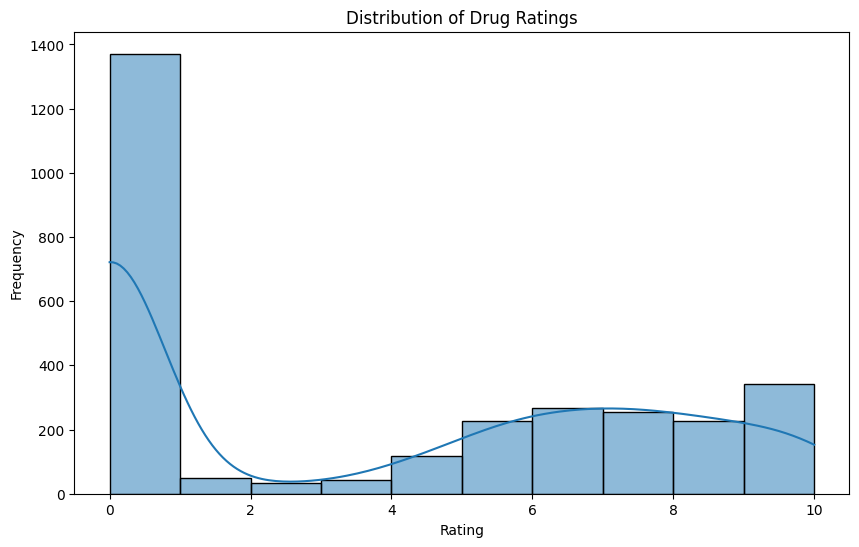

In [11]:
#visualization
#Distribution of drug ratings
plt.figure(figsize=(10,6))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('Distribution of Drug Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [12]:
#Most common medical condition (top 10)
df['medical_condition'].value_counts().head(10)

,count
medical_condition,
Pain,264
Colds & Flu,245
Acne,238
Hypertension,177
Osteoarthritis,129
Hayfever,124
Eczema,122
AIDS/HIV,109
Diabetes (Type 2),104


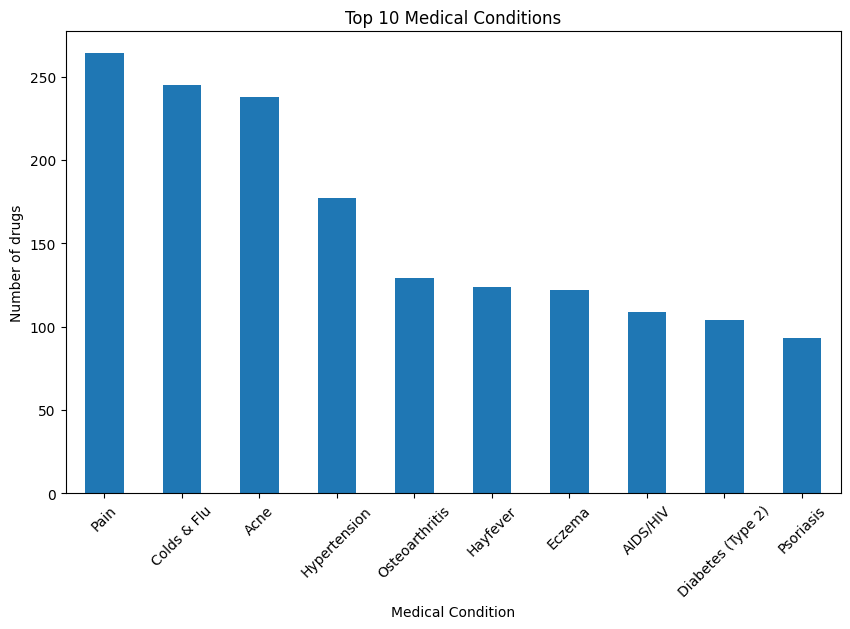

In [13]:
#visualizing top 10 medical condition
plt.figure(figsize=(10,6))
df['medical_condition'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Medical Conditions')
plt.xlabel('Medical Condition')
plt.ylabel('Number of drugs')

plt.xticks(rotation=45)
plt.show()


In [14]:
#Analysing and visualising side_effects
#Many side effects are written in one cell, hence splitting and arranging it in order.
import re

def extract_side_effects(text):
      return [effect.strip()for effect in text.split(';')]

side_effects = df['side_effects'].apply (extract_side_effects)

side_effects




,side_effects
0,"[(hives, difficult breathing, swelling in your..."
1,"[hives, difficulty breathing, swelling of your..."
2,"[skin rash, fever, swollen glands, flu-like sy..."
3,"[problems with your vision or hearing, muscle ..."
4,"[hives, difficult breathing, swelling of your ..."
...,...
2926,"[hives, difficulty breathing, swelling of your..."
2927,"[hives, difficult breathing, swelling of your ..."
2928,[Unknown]
2929,"[Imcivree may cause serious side effects, incl..."


In [15]:
side_effects = side_effects.explode()
side_effects

,side_effects
0,"(hives, difficult breathing, swelling in your ..."
0,"throat irritation, trouble swallowing"
0,"chest pain, irregular heart rhythm, feeling sh..."
0,little or no urination
0,"low white blood cell counts - fever, chills, s..."
...,...
2930,"swelling of your face, lips, tongue, or throat..."
2930,skin darkening
2930,headache
2930,erection without any sexual activity in males


In [16]:
# Side effect count based on the number of times of appearance.
side_effects_counts = side_effects.value_counts().head(10)
side_effects_counts

,count
side_effects,
hives,1788
difficult breathing,1130
difficulty breathing,450
itching,275
"a light-headed feeling, like you might pass out",272
unusual hoarseness,266
"trouble breathing, swallowing, or talking",266
tightness in the chest or throat,266
wheezing,266


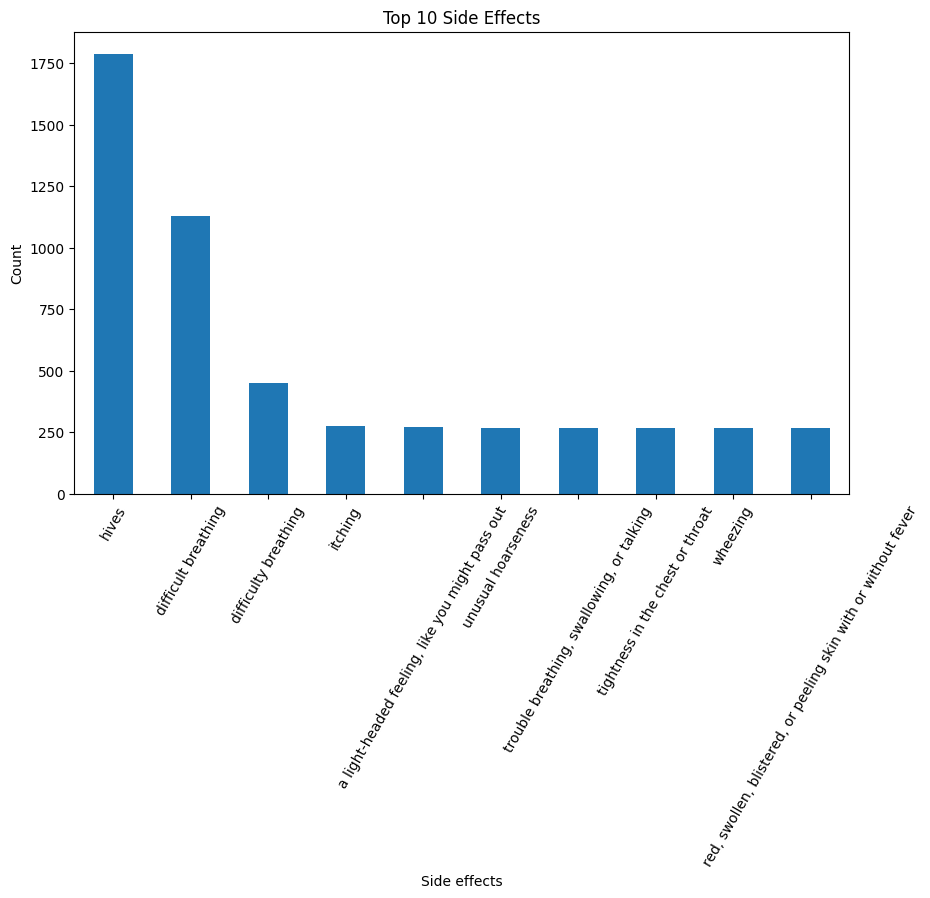

In [17]:
#visualizing top 10 side effects
plt.figure(figsize=(10,6))
side_effects_counts.plot(kind='bar')

plt.title('Top 10 Side Effects')
plt.xlabel('Side effects')
plt.ylabel('Count')

plt.xticks(rotation=60)
plt.show()


In [18]:
##extracting top 10 drug classes
top_classes = df['drug_classes'].value_counts().head(10).index
df_top = df[df['drug_classes'].isin(top_classes)]


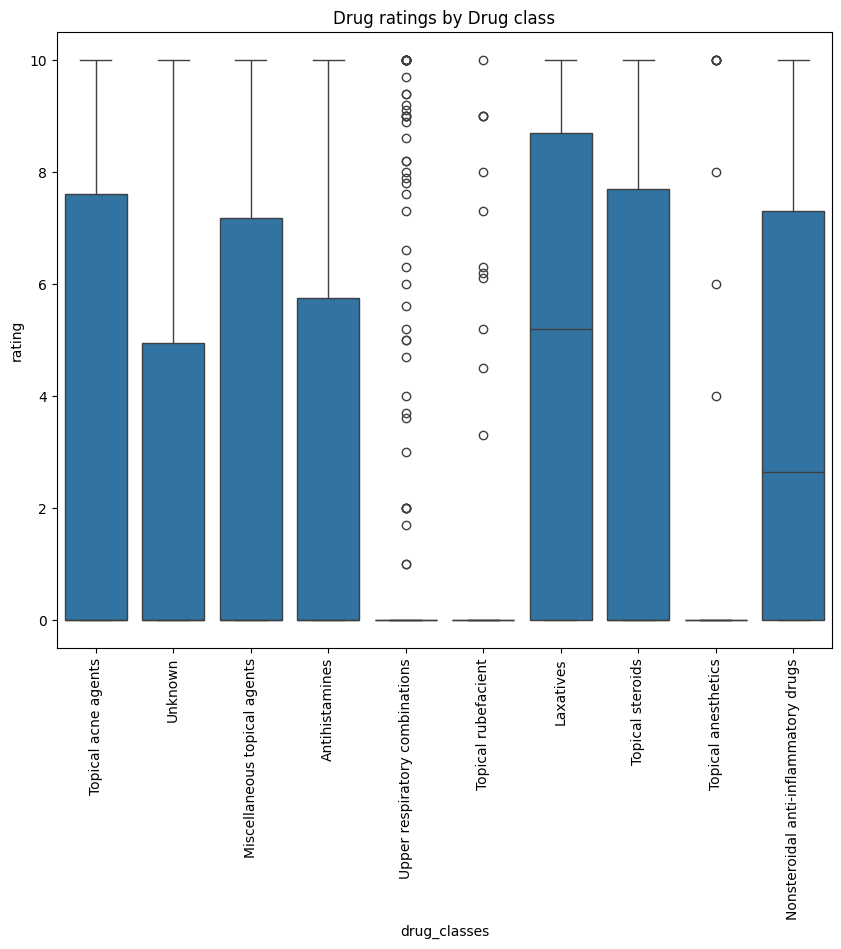

In [19]:
# visualising drug ratings by drug class
plt.figure(figsize=(10,8))
sns.boxplot(x='drug_classes', y= 'rating', data =df_top)

plt.xticks(rotation=90)
plt.title('Drug ratings by Drug class')
plt.show()


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['generic_name'] = le.fit_transform(df['generic_name'])
df['medical_condition'] = le.fit_transform(df['medical_condition'])
df['pregnancy_category'] = le.fit_transform(df['pregnancy_category'])
df['rx_otc'] = le.fit_transform(df['rx_otc'])
df['csa'] = le.fit_transform(df['csa'])


In [21]:
df_model = df[['generic_name',
               'medical_condition',
               'rating',
               'no_of_reviews',
               'pregnancy_category',
               'rx_otc',
               'csa',
               'alcohol']]

In [22]:
#creating correlation heatmap
correl= df_model.corr()
correl

,generic_name,medical_condition,rating,no_of_reviews,pregnancy_category,rx_otc,csa,alcohol
generic_name,1.000000,0.015467,0.163913,0.098939,-0.086735,0.041873,-0.050001,-0.035279
medical_condition,0.015467,1.000000,-0.032792,-0.024739,-0.014289,0.022195,-0.075679,0.002977
rating,0.163913,-0.032792,1.000000,0.217858,0.004731,-0.057234,-0.157163,0.094445
no_of_reviews,0.098939,-0.024739,0.217858,1.000000,0.038573,-0.040180,-0.146258,0.115464
pregnancy_category,-0.086735,-0.014289,0.004731,0.038573,1.000000,-0.138719,-0.025689,0.055809
rx_otc,0.041873,0.022195,-0.057234,-0.040180,-0.138719,1.000000,0.038185,0.026253
csa,-0.050001,-0.075679,-0.157163,-0.146258,-0.025689,0.038185,1.000000,-0.262187
alcohol,-0.035279,0.002977,0.094445,0.115464,0.055809,0.026253,-0.262187,1.000000


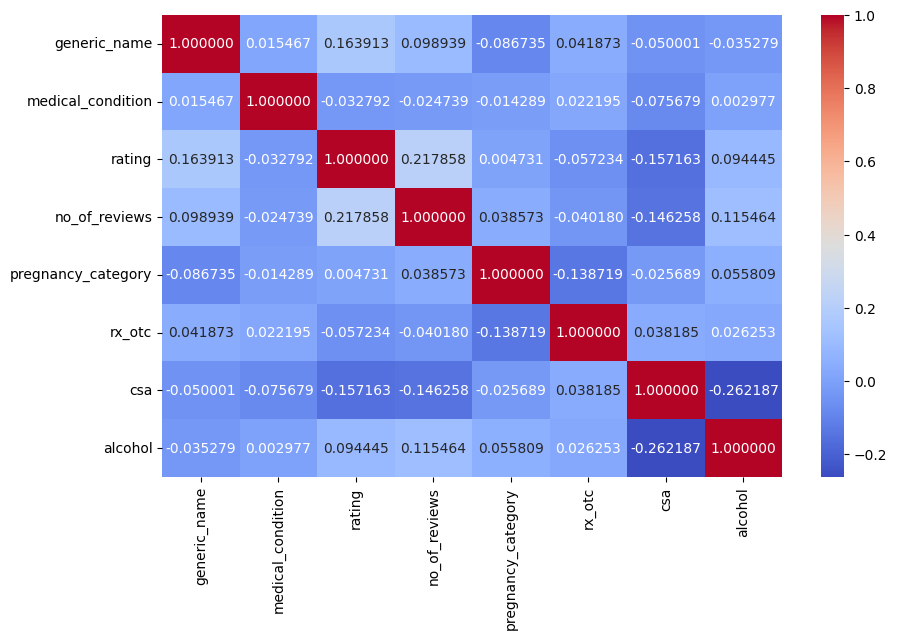

In [23]:
plt.figure(figsize=(10,6))

sns.heatmap(correl, annot=True, cmap="coolwarm", fmt ="2f")


plt.show()

By heatmap, it tells that more reviews are tend to have slightly
higher ratings.


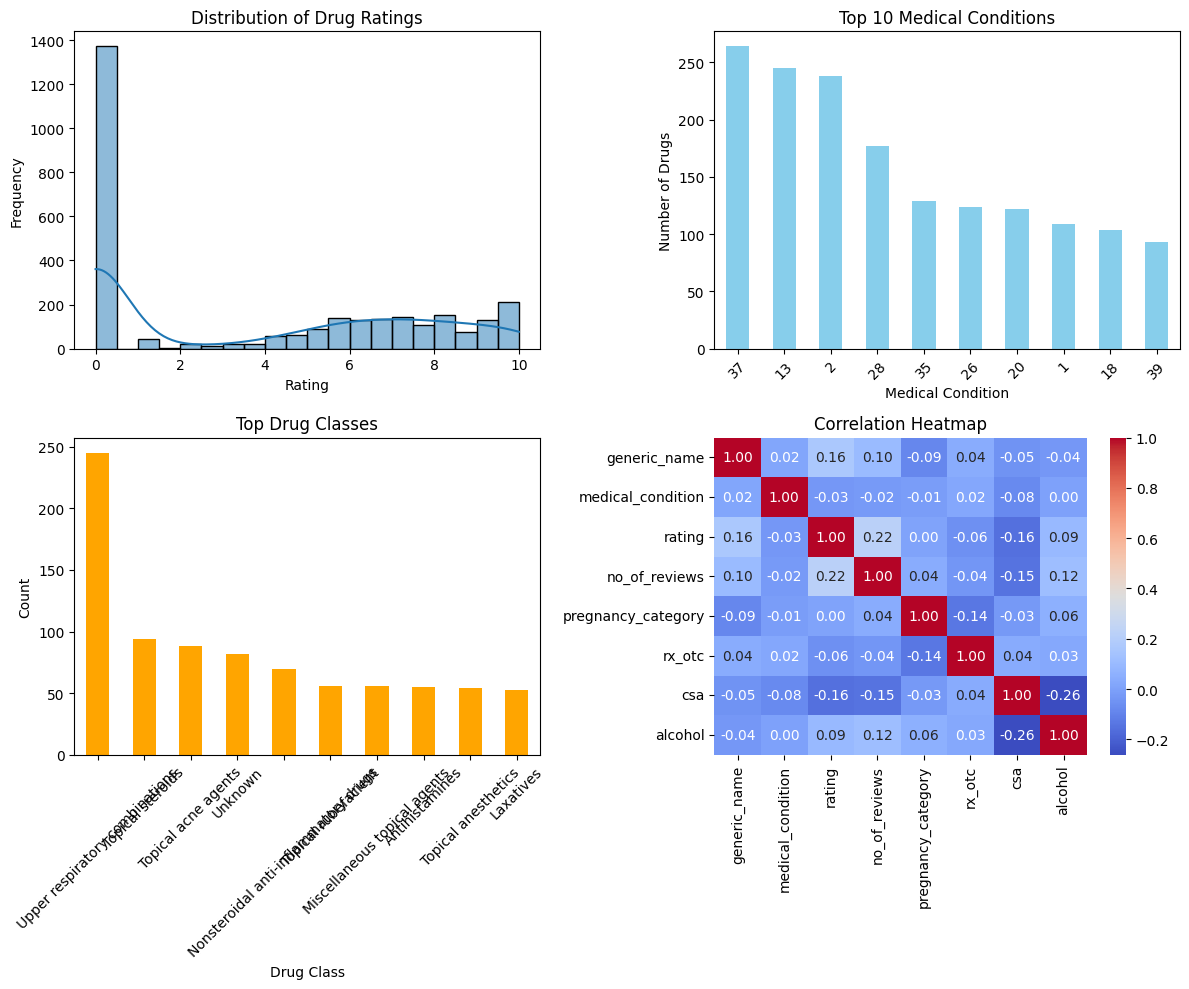

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# create dashboard layout
plt.figure(figsize=(12,10))

# 1️⃣ Rating Distribution
plt.subplot(2,2,1)
sns.histplot(df['rating'], bins=20, kde=True)
plt.title("Distribution of Drug Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

# 2️⃣ Top Medical Conditions
plt.subplot(2,2,2)
df['medical_condition'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Medical Conditions")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Drugs")
plt.xticks(rotation=45)

# 3️⃣ Top Drug Classes
plt.subplot(2,2,3)
df['drug_classes'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title("Top Drug Classes")
plt.xlabel("Drug Class")
plt.ylabel("Count")
plt.xticks(rotation=45)

# 4️⃣ Correlation Heatmap
plt.subplot(2,2,4)
corr = df_model.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()